# Membrane visualization notebook

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from pathlib import Path

# Add the folder that CONTAINS membrane_analysis/ to the path
sys.path.insert(0, str(Path("..").resolve()))  # adjust if needed

from membrane_analysis.utils import rdf, nndf, min_neigbor_distance, flood_fill, cluster_sizes

from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cma
import matplotlib as mlp
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import gc 
from matplotlib import cm, colors
from scipy.stats import gaussian_kde
from shapely.geometry import box
from shapely.ops import unary_union
from skimage.morphology import dilation, disk
from scipy.optimize import curve_fit



import cyanomembranes as cm


# Random generator
RNG = np.random.default_rng(seed=0)


N_PROCESSES = 10



## Visualize protein shadows

In [2]:
PDB_FILES = [
    "1JB0-PSI-syn-cocc.pdb",
    "1NEK-SDH-Ecoli.pdb",
    "1OCO-cytoxidase-bov.trpdb",
    "1xl4-Kchannel-Pmagnetotacticum.trpdb",
    "3WU2-PSII-ThermosynVul.pdb",
    "4H13-cytb6f.trpdb",
]

DATA = Path("../data_cyano/")
(OUT := Path("../output")).mkdir(exist_ok=True)
(PIC_DIR :=  (OUT/"pictures_membranes")).mkdir(exist_ok=True)

proteins = cm.pdb_utils.process_proteins(DATA, OUT / "protein_shadows", PDB_FILES)


/home/tim/Gitrepos/cyanomembranes/.pixi/envs/default/lib/python3.13/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Could not assign element 'M' for Atom (name=MG) with given element 'M'
  warnings.warn(msg, PDBConstructionWarning)
/home/tim/Gitrepos/cyanomembranes/.pixi/envs/default/lib/python3.13/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Could not assign element 'Z' for Atom (name=ZN) with given element 'Z'
  warnings.warn(msg, PDBConstructionWarning)
/home/tim/Gitrepos/cyanomembranes/.pixi/envs/default/lib/python3.13/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Could not assign element 'M' for Atom (name=MG) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)
/home/tim/Gitrepos/cyanomembranes/.pixi/envs/default/lib/python3.13/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Could not assign element 'Z' for Atom (name=ZN) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)
/home/tim/Gitrepos/cyanomemb

1JB0-PSI-syn-cocc: difference centroid and COM 0.04
1NEK-SDH-Ecoli: difference centroid and COM 0.00
1OCO-cytoxidase-bov: difference centroid and COM 0.00
1xl4-Kchannel-Pmagnetotacticum: difference centroid and COM 0.30
3WU2-PSII-ThermosynVul: difference centroid and COM 0.21
4H13-cytb6f: difference centroid and COM 0.00


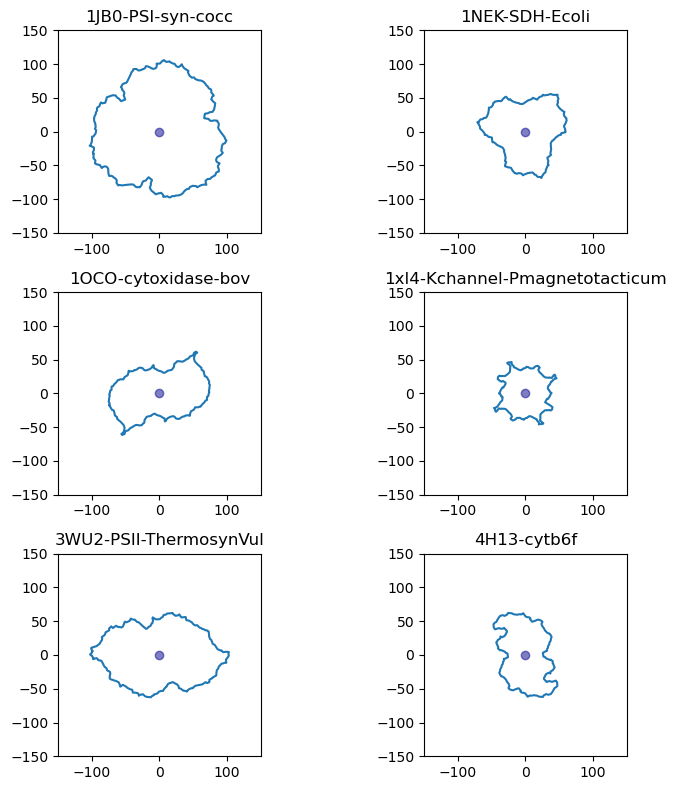

In [3]:
fig, ax = plt.subplots(3, 2, figsize=(8, 8))
ax = ax.flatten()
for i, prot in enumerate(proteins):
    polygon = proteins[prot]["polygon"]
    centroid = np.array(polygon[0].centroid.xy).T[0]
    com = proteins[prot]["center_of_mass"][:-1] # 2D projection
    ax[i].plot(*polygon[0].exterior.xy)
    ax[i].scatter(*centroid, c="yellow", alpha=0.5)
    ax[i].scatter(*com, c="blue", alpha=0.5)
    ax[i].set_aspect("equal")
    ax[i].set_title(prot)
    ax[i].set_xlim(-150, 150)
    ax[i].set_ylim(-150, 150)

    diff = np.linalg.norm(centroid - com, ord=2)
    print(f"{prot}: difference centroid and COM {diff:.2f}")

plt.tight_layout()
fig.show()

## Define plotting function

In [ ]:
def plot_membrane(filepath, ax, legend = False):
    p = cm.geo_utils.readwkt(filepath)
    psi_area = proteins["1JB0-PSI-syn-cocc"]["polygon"][0].area
    psii_area = proteins["3WU2-PSII-ThermosynVul"]["polygon"][0].area
    cytb6f_area = proteins["4H13-cytb6f"]["polygon"][0].area

    pastel_blue = "#A2CFFE"
    pastel_yellow = "#F7E1B5"
    pastel_green = "#A9E5B8"
    pastel_darkblue = "#54A5FC"

    psii_lst = []
    for i in p:
        if np.isclose(i.area, psi_area):
            ax.fill(*i.exterior.xy, lw=0.4, c=pastel_blue, edgecolor="grey")
        if np.isclose(i.area, psii_area):
            ax.fill(*i.exterior.xy, lw=0.4, c=pastel_yellow, edgecolor="grey")
            psii_lst.append(i)
        if np.isclose(i.area, cytb6f_area):
            ax.fill(*i.exterior.xy, lw=0.4, c="red", edgecolor="grey")

    if legend:
        legend_handles = [
        Patch(facecolor=pastel_blue, edgecolor="grey", label="PSI"),
        Patch(facecolor=pastel_yellow, edgecolor="grey", label="PSII"),
        Patch(facecolor="red", edgecolor="grey", label=r"Cyt $\mathrm{b_6f}$")
        ]

        ax.legend(handles=legend_handles)


    ax.set_aspect("equal")
    ax.set_xlim(0,5000)
    ax.set_ylim(0,5000)
    ax.set_ylabel(r"$\mathrm{\AA}$")
    ax.set_xlabel(r"$\mathrm{\AA}$")
    

def get_complex_idx(p):
    psi_area = proteins["1JB0-PSI-syn-cocc"]["polygon"][0].area
    psii_area = proteins["3WU2-PSII-ThermosynVul"]["polygon"][0].area
    cytb6f_area = proteins["4H13-cytb6f"]["polygon"][0].area
    psii_idx = []
    psi_idx = []
    psimono_idx =  []
    cytb6f_idx = []
    for idx, i in enumerate(p):
        if np.isclose(i.area, psi_area):
            psi_idx.append(idx)
        if np.isclose(i.area, psii_area):
            psii_idx.append(idx)
        if np.isclose(i.area, cytb6f_area):
            cytb6f_idx.append(idx)
    return {"PSI": psi_idx, "PSII": psii_idx, "Cytb6f": cytb6f_idx}

## Average membranes

/tmp/ipykernel_139716/17984601.py:99: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


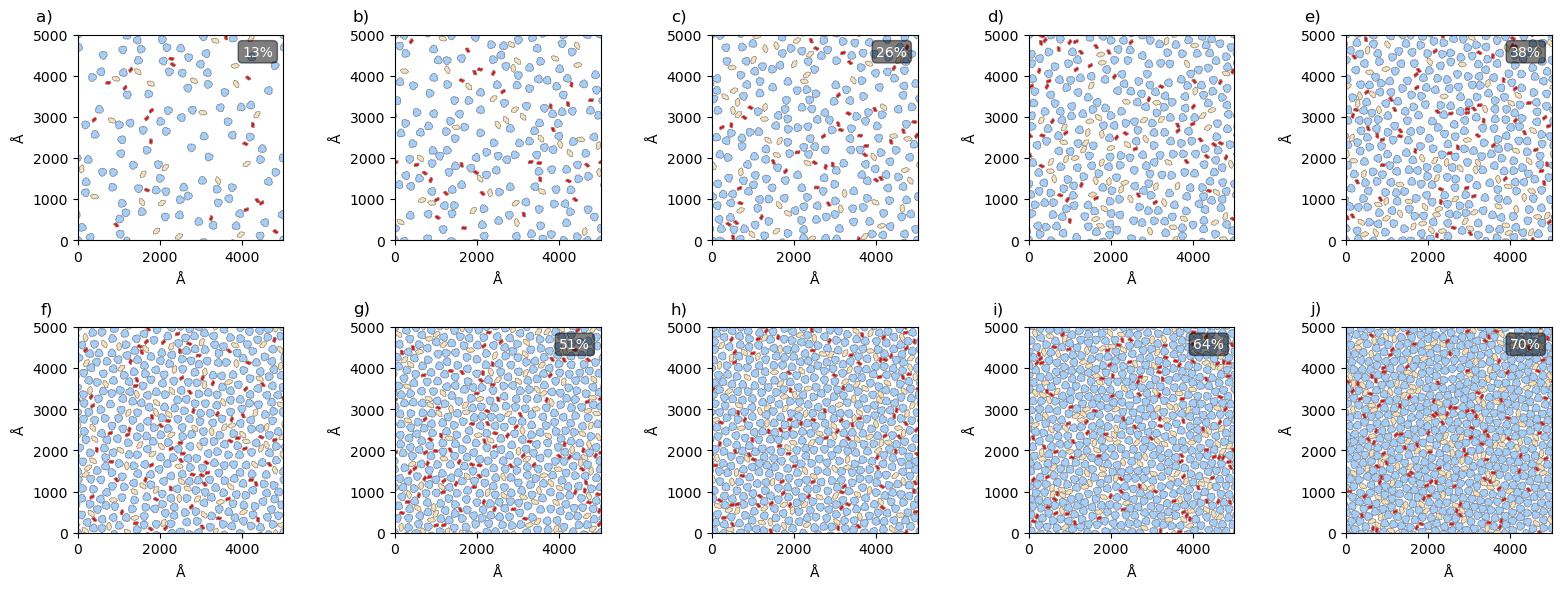

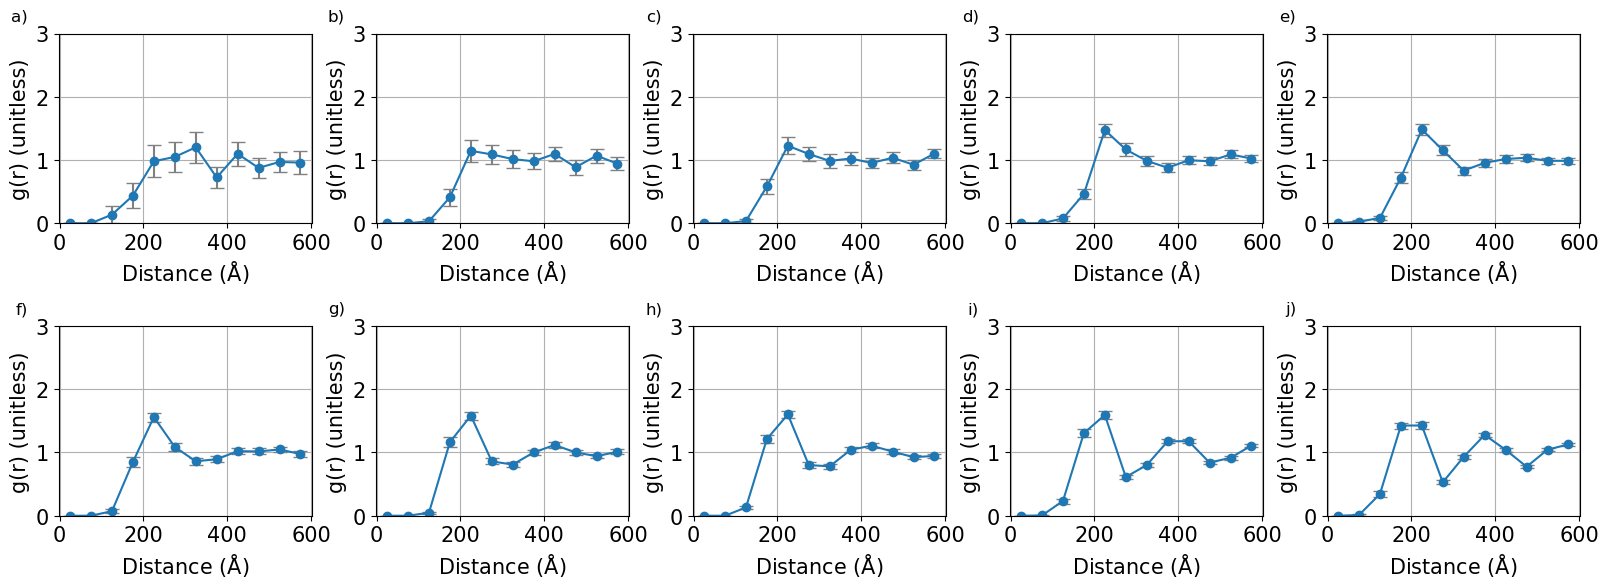

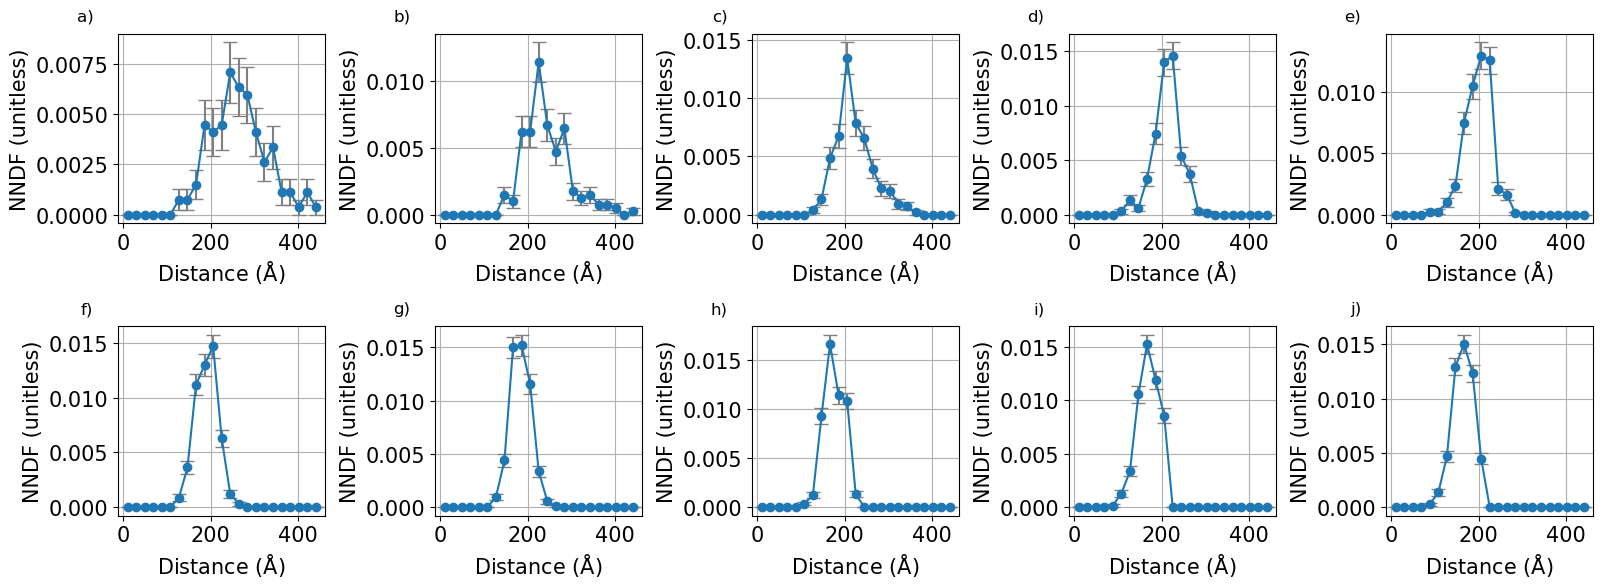

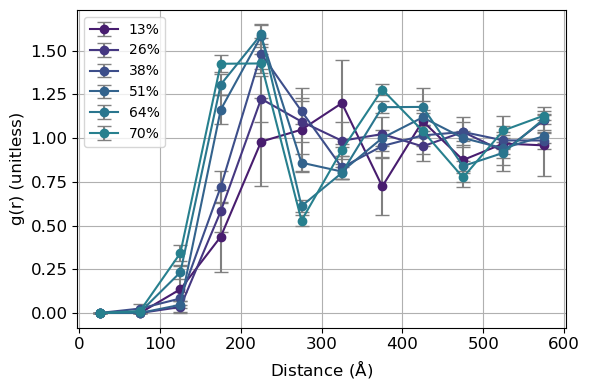

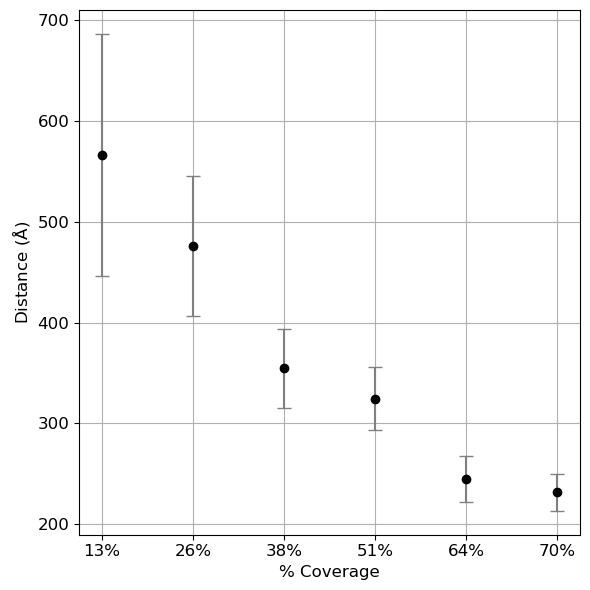

In [5]:
number_to_cov = {20: "13%", 40:"26%", 60:"38%", 80:"51%", 100: "64%", 110:"70%"}

layout = [
    ["a", "b", "c", "d", "e"],
    ["f", "g", "h", "i", "j"],
]

fig, axes = plt.subplots(2, 5, figsize=(2*8, 6), constrained_layout=True)
fig2, axes2 = plt.subplots(2, 5, figsize=(2*8, 6))
fig3, axes3 = plt.subplots(2, 5, figsize=(2*8, 6))
fig4, ax4 = plt.subplots(figsize=(6,4))
fig5, ax5 = plt.subplots(figsize=(6,6))
gr_container = {}

values = range(20, 120, 120)
norm = colors.Normalize(vmin=min(values), vmax=max(values))
cmap = mlp.colormaps["viridis"]

for ax, ax2, ax3, i in zip(axes.flatten(), axes2.flatten(), axes3.flatten(), range(20, 120, 10)):
    plot_membrane(
        f"../output/avg_membrane/polygons_avg_membrane_{i}-0.wkt",
        ax=ax)

    if i in number_to_cov.keys():
        ax.text(0.95, 0.95, number_to_cov[i],
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=10,
                color='white',
                bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))

    p = cm.geo_utils.readwkt(Path(f"../output/avg_membrane/polygons_avg_membrane_{i}-0.wkt"))
    complex_idxs = get_complex_idx(p)
    centroids = np.array([i.centroid.xy for i in p])  
    centroids = centroids.reshape(len(centroids),2)
    gr, gr_std, gr_sem, r = rdf(centroids, n_bins=12, box_size=5000, r_max=600)
    G_empirical, G_std, g_nn_empirical, g_nn_std, r2 = nndf(centroids, n_bins=23, box_size = 5000, r_max=450)
    psii_cytb6f_dist = min_neigbor_distance(
        polygons=centroids,
        start_idx=complex_idxs["PSII"],
        target_idx=complex_idxs["Cytb6f"],
        box_size=5000
    )

    ax2.errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
    ax2.grid()
    ax2.tick_params(axis="both", labelsize=15)
    ax2.set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
    ax2.set_ylabel("g(r) (unitless)", size=15)
    ax2.set_ylim(0, 3)

    ax3.errorbar(r2, g_nn_empirical, g_nn_std, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
    ax3.grid()
    ax3.tick_params(axis="both", labelsize=15)
    ax3.set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
    ax3.set_ylabel("NNDF (unitless)", size=15)

    if i in [20, 40, 60, 80, 100, 110]:
        ax4.errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6, label=number_to_cov[i], color=cmap(i))
        gr_container[i] = gr

        psii_cytb6f_dist_sem = psii_cytb6f_dist.std(ddof=1) / np.sqrt(len(psii_cytb6f_dist))
        ax5.errorbar(number_to_cov[i], psii_cytb6f_dist.mean(), 1.96*psii_cytb6f_dist_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6, color="black")

gr_container["Distance"] = r

ax4.grid()
ax4.tick_params(axis="both", labelsize=12)
ax4.set_xlabel(r"Distance ($\mathrm{\AA}$)", size=12)
ax4.set_ylabel("g(r) (unitless)", size=12)
ax4.legend()

ax5.grid()
ax5.tick_params(axis="both", labelsize=12)
ax5.set_ylabel(r"Distance ($\mathrm{\AA}$)", size=12)
ax5.set_xlabel("% Coverage", size=12)


flat_labels = [key for row in layout for key in row]

for ax, key in zip(axes.flatten(), flat_labels):
    ax.text(-0.12, 1.05, f"{key})",
           transform=ax.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax2, key in zip(axes2.flatten(), flat_labels):
    ax2.text(-0.12, 1.05, f"{key})",
           transform=ax2.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax3, key in zip(axes3.flatten(), flat_labels):
    ax3.text(-0.12, 1.05, f"{key})",
           transform=ax3.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)

fig.tight_layout()
fig.savefig(PIC_DIR/ "average_membrane.png", dpi = 300)

fig2.tight_layout()
fig2.savefig(PIC_DIR/ "rdf_average_membrane.png", dpi = 300)

fig3.tight_layout()
fig3.savefig(PIC_DIR/ "nndf_average_membrane.png", dpi = 300)

fig4.tight_layout()
fig4.savefig(PIC_DIR/ "all_rdf_average_membrane.png", dpi = 300)

fig5.tight_layout()
fig5.savefig(PIC_DIR/ "psii_cytb6f_min_distance.png", dpi = 300)

## Plot membrane with PSI crystaline arrays (one big array)

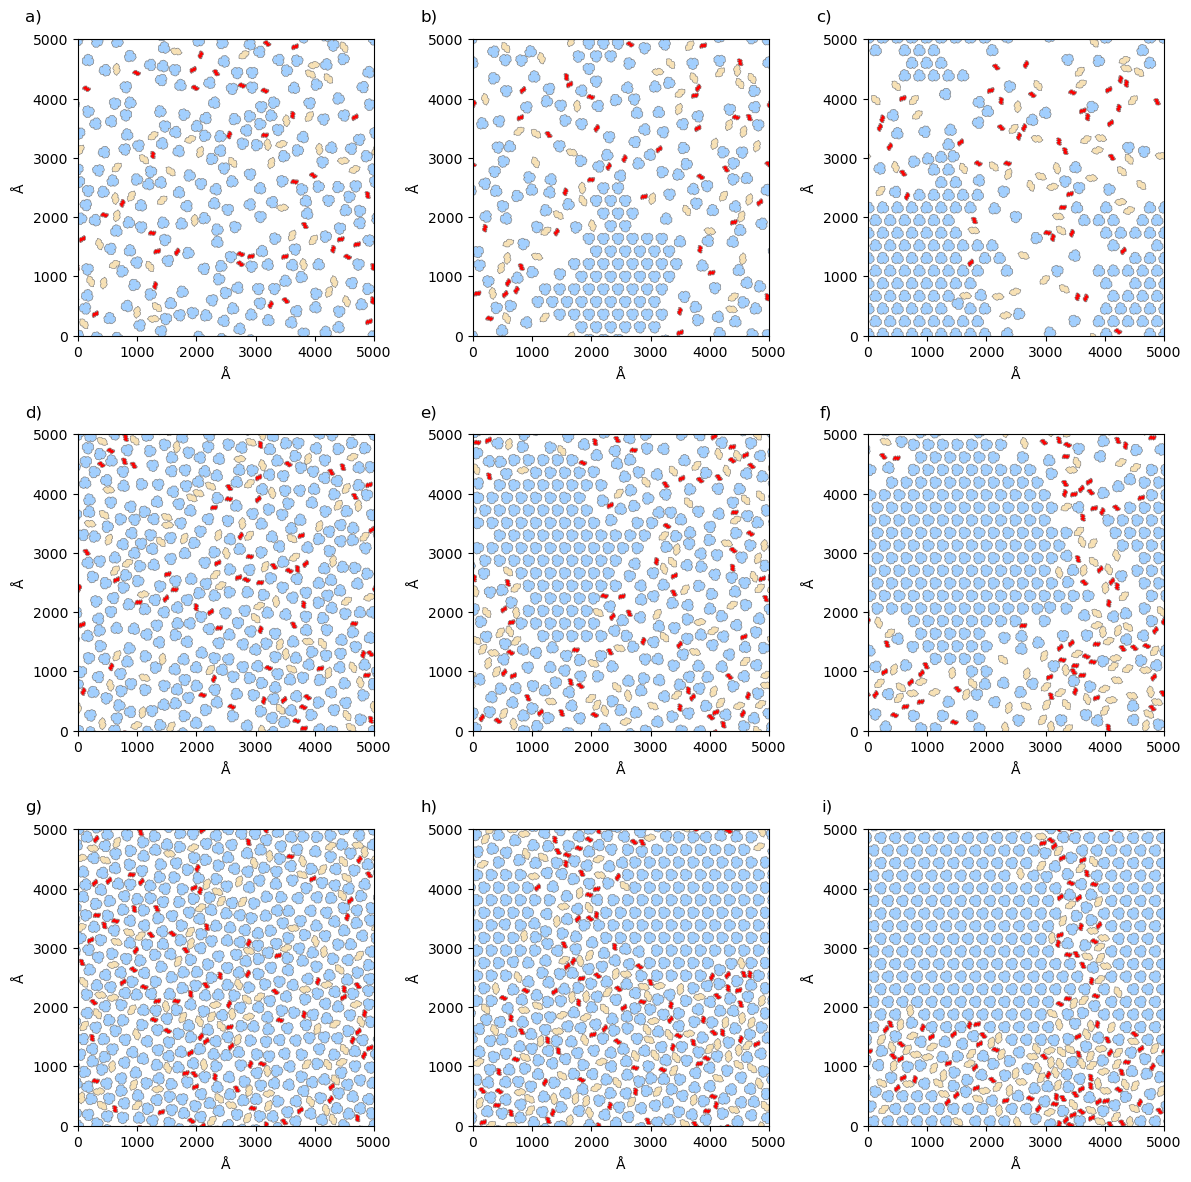

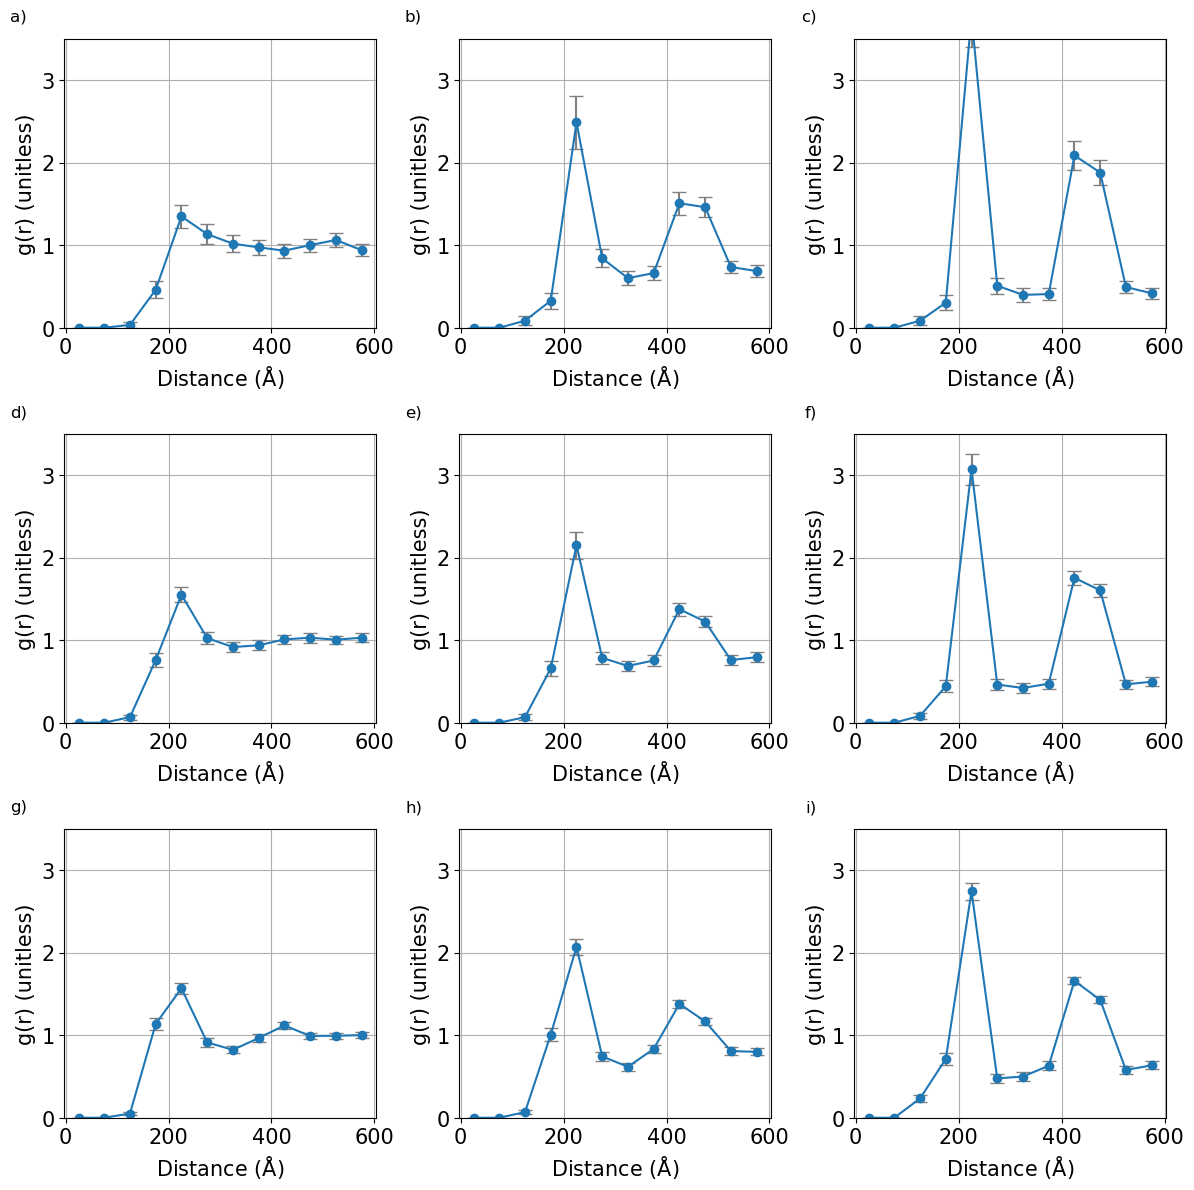

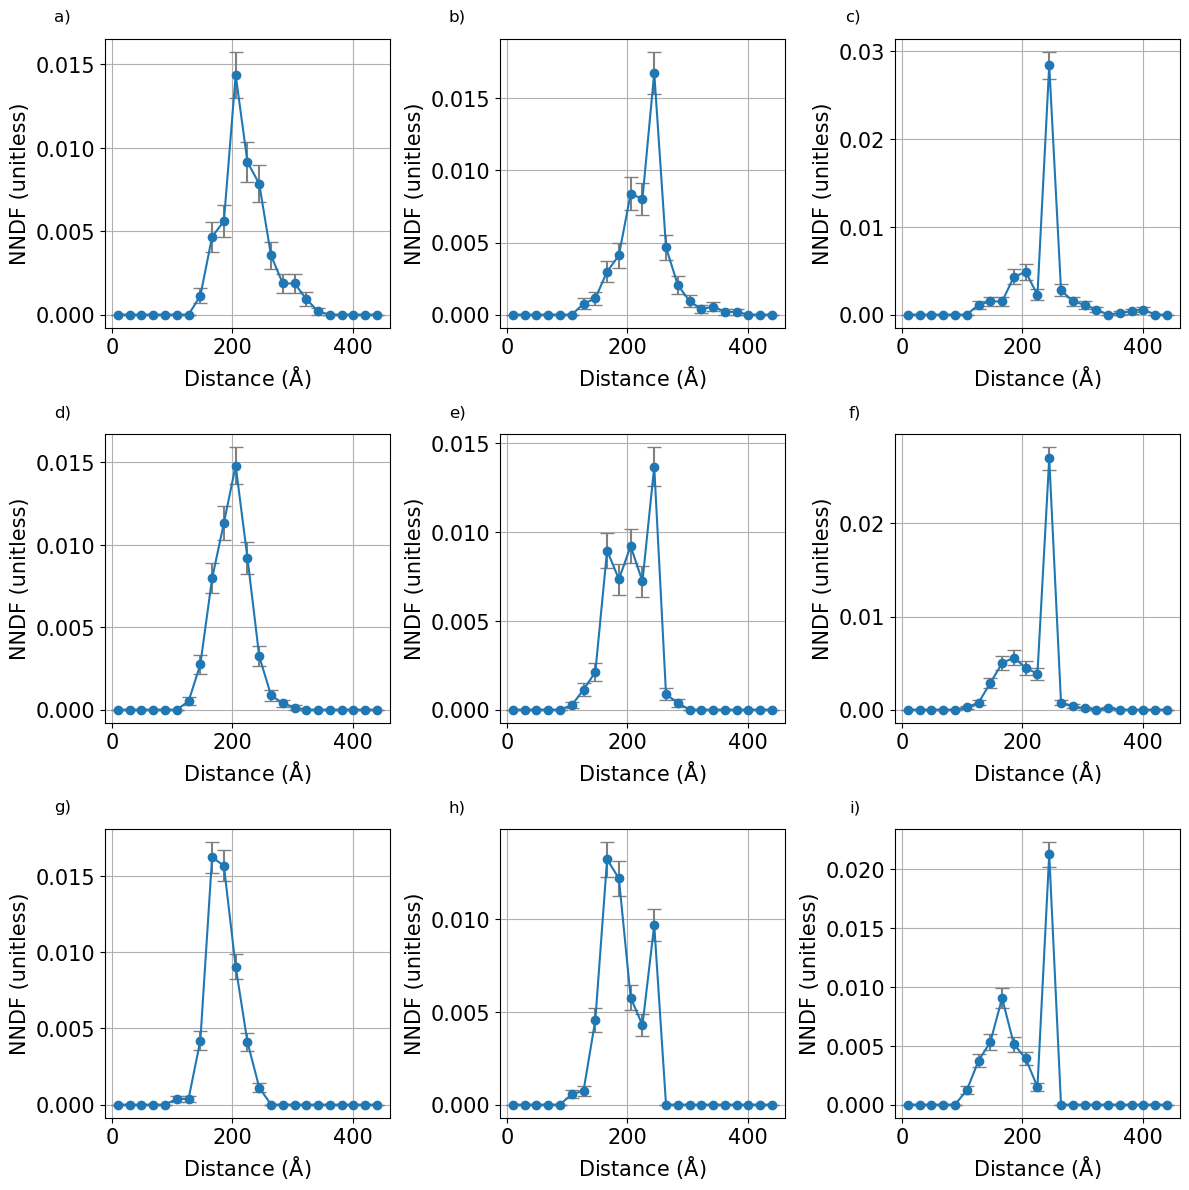

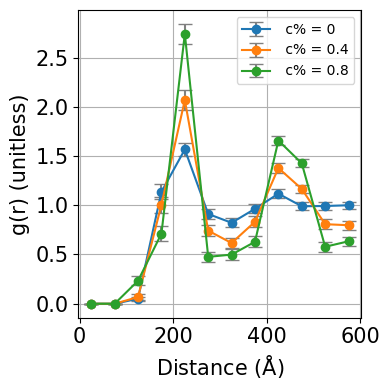

In [6]:
layout = [
    ["a", "b", "c"],
    ["d", "e", "f"],
    ["g", "h", "i"],
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig2, axes2 = plt.subplots(3, 3, figsize=(12, 12))
fig3, axes3 = plt.subplots(3, 3, figsize=(12, 12))
fig4, ax4 = plt.subplots(figsize=(4,4))

for idx1, i in enumerate([40, 60, 80]):
    for idx2,j in enumerate([0, 0.4, 0.8]):
        plot_membrane(
            f"../output/avg_membrane_1JB0-PSI-syn-cocc_crystal/polygons_avg_membrane_{i}_1JB0-PSI-syn-cocc_1.2_{j}_1-1.wkt",
            ax=axes[idx1, idx2]
            )

        p = cm.geo_utils.readwkt(Path(f"../output/avg_membrane_1JB0-PSI-syn-cocc_crystal/polygons_avg_membrane_{i}_1JB0-PSI-syn-cocc_1.2_{j}_1-1.wkt"))
        centroids = np.array([i.centroid.xy for i in p])  # your input
        centroids = centroids.reshape(len(centroids),2)
        gr, gr_std, gr_sem, r = rdf(centroids, n_bins=12, box_size=5000, r_max=600)
        G_empirical, G_std, g_nn_empirical, g_nn_std, r2 = nndf(centroids, n_bins=23, box_size = 5000, r_max=450)

        axes2[idx1, idx2].errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes2[idx1, idx2].grid()
        axes2[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes2[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes2[idx1, idx2].set_ylabel("g(r) (unitless)", size=15)
        axes2[idx1, idx2].set_ylim(0, 3.5)

        axes3[idx1, idx2].errorbar(r2, g_nn_empirical, g_nn_std, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes3[idx1, idx2].grid()
        axes3[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes3[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes3[idx1, idx2].set_ylabel("NNDF (unitless)", size=15)

        if i in [80]:
            ax4.errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6, label=f" c% = {str(j)}")

ax4.grid()
ax4.tick_params(axis="both", labelsize=15)
ax4.set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
ax4.set_ylabel("g(r) (unitless)", size=15)
ax4.legend()

flat_labels = [key for row in layout for key in row]

for ax, key in zip(axes.flatten(), flat_labels):
    ax.text(-0.12, 1.05, f"{key})",
           transform=ax.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax2, key in zip(axes2.flatten(), flat_labels):
    ax2.text(-0.12, 1.05, f"{key})",
           transform=ax2.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax3, key in zip(axes3.flatten(), flat_labels):
    ax3.text(-0.12, 1.05, f"{key})",
           transform=ax3.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)


fig.tight_layout()
fig.savefig(PIC_DIR/ "psi_crystals_membrane.png", dpi = 300)

fig2.tight_layout()
fig2.savefig(PIC_DIR/ "rdf_psi_crystals_membrane.png", dpi = 300)

fig3.tight_layout()
fig3.savefig(PIC_DIR/ "nndf_psi_crystals_membrane.png", dpi = 300)

fig4.tight_layout()
fig4.savefig(PIC_DIR/ "all_rdf_psi_crystals_membrane.png", dpi = 300)


## Plot membrane with PSI crystaline arrays (four small array)

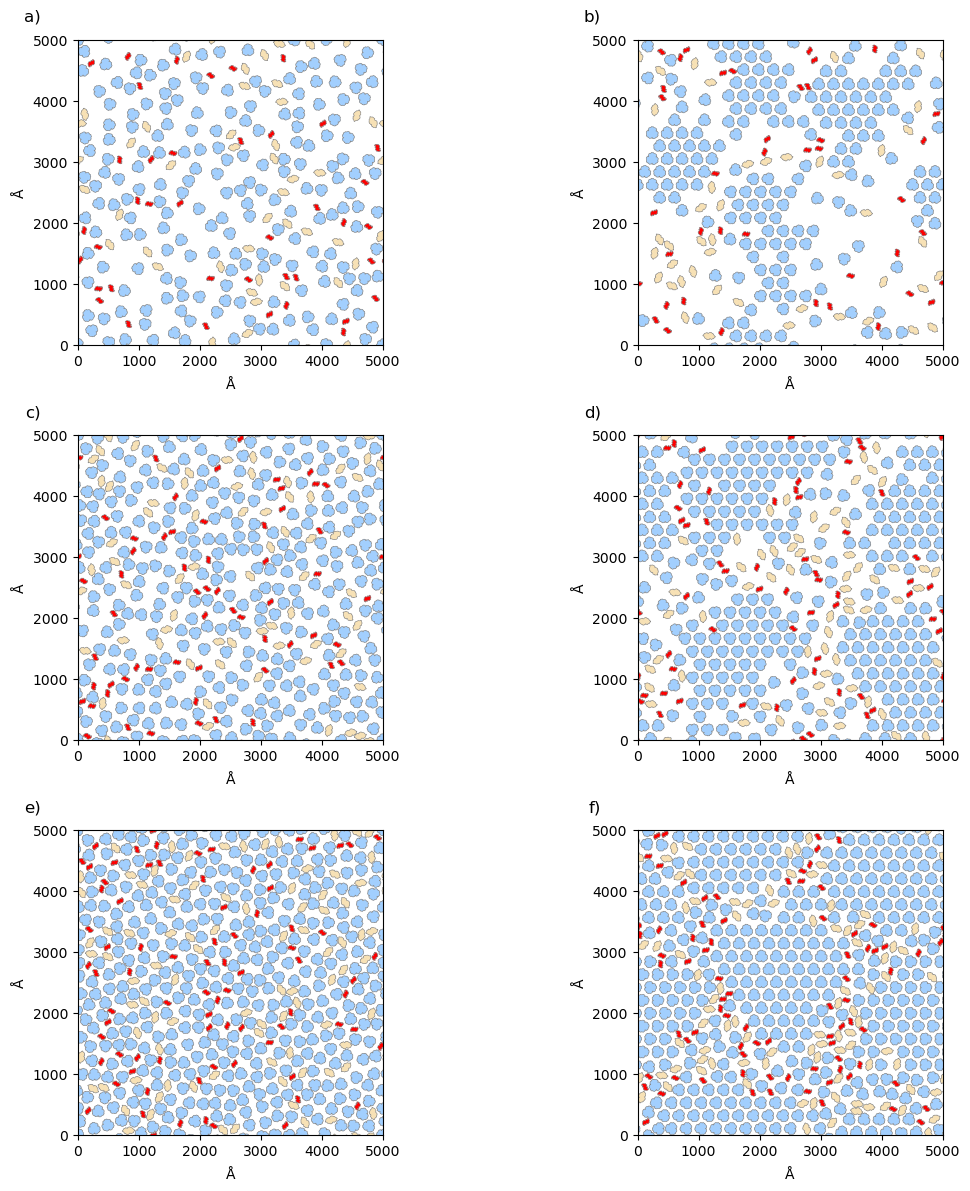

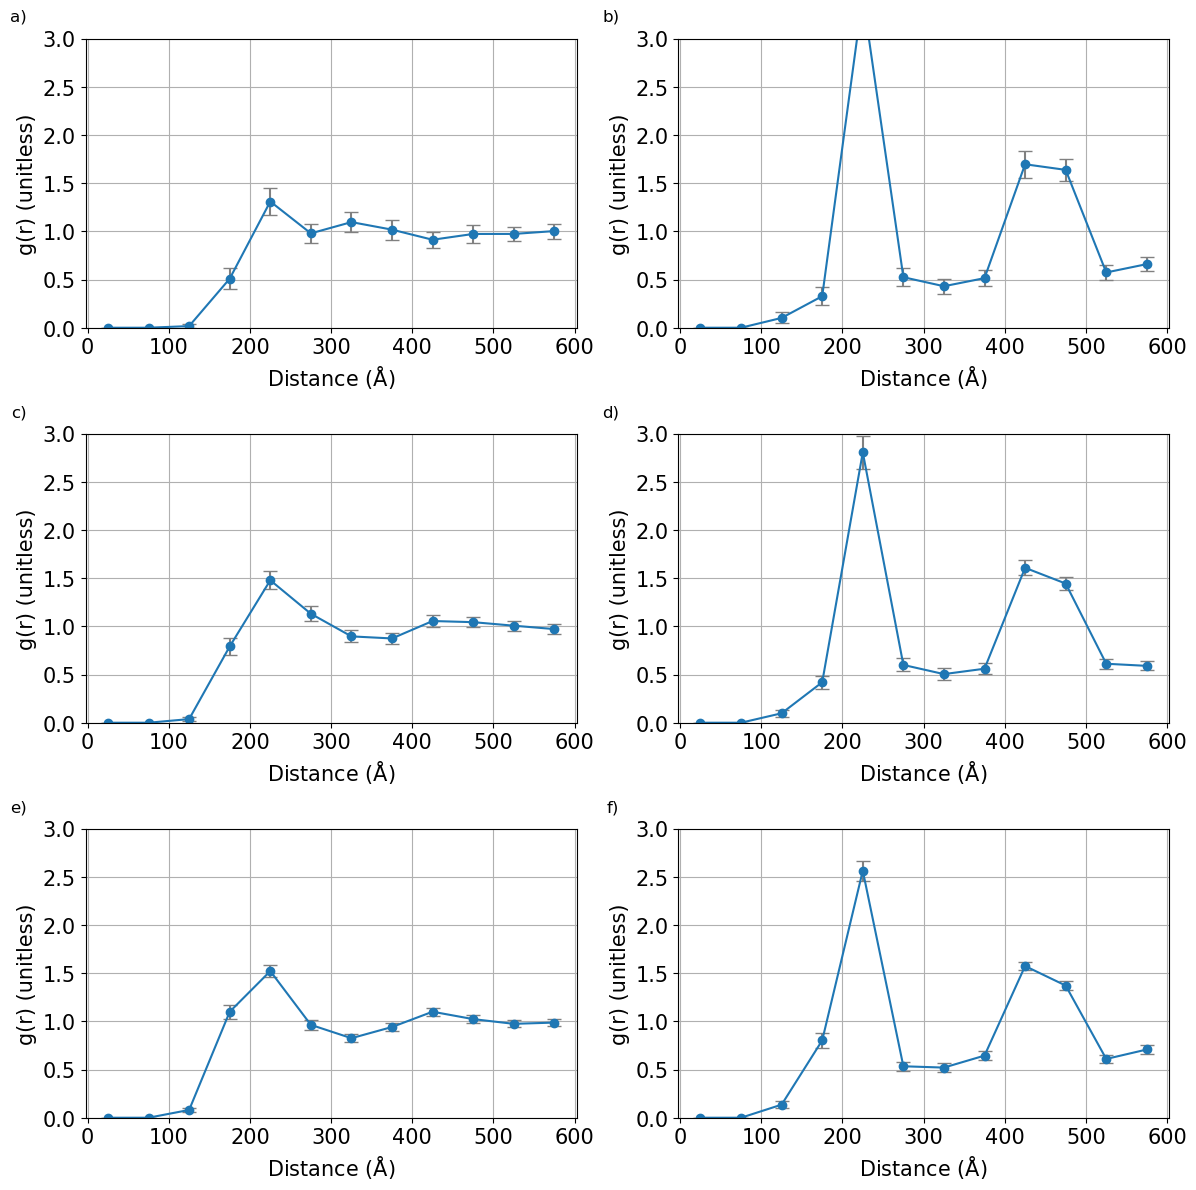

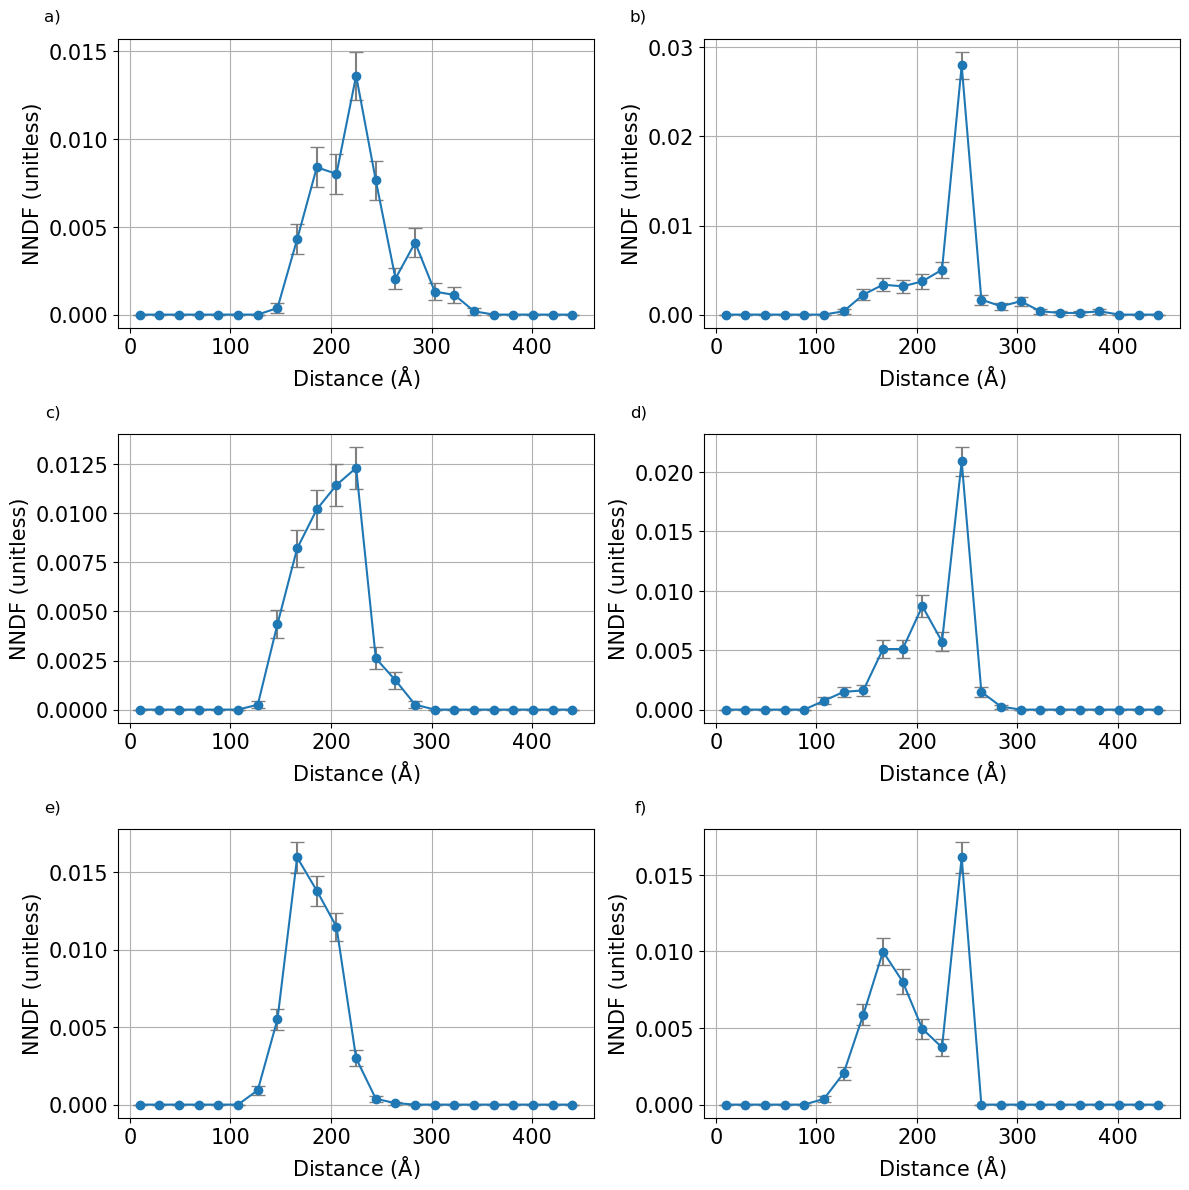

In [7]:
layout = [
    ["a", "b"],
    ["c", "d"],
    ["e", "f"],
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig2, axes2 = plt.subplots(3, 2, figsize=(12, 12))
fig3, axes3 = plt.subplots(3, 2, figsize=(12, 12))



for idx1, i in enumerate([40, 60, 80]):
    for idx2,j in enumerate([0, 0.2]):
        plot_membrane(
            f"../output/avg_membrane_1JB0-PSI-syn-cocc_crystal_small/polygons_avg_membrane_{i}_1JB0-PSI-syn-cocc_1.2_{j}_4-1.wkt",
            ax=axes[idx1, idx2]
            )

        p = cm.geo_utils.readwkt(Path(f"../output/avg_membrane_1JB0-PSI-syn-cocc_crystal_small/polygons_avg_membrane_{i}_1JB0-PSI-syn-cocc_1.2_{j}_4-1.wkt"))
        centroids = np.array([i.centroid.xy for i in p])  # your input
        centroids = centroids.reshape(len(centroids),2)
        gr, gr_std, gr_sem, r = rdf(centroids, n_bins=12, box_size=5000, r_max=600)
        G_empirical, G_std, g_nn_empirical, g_nn_std, r2 = nndf(centroids, n_bins=23, box_size = 5000, r_max=450)

        axes2[idx1, idx2].errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes2[idx1,idx2].grid()
        axes2[idx1,idx2].tick_params(axis="both", labelsize=15)
        axes2[idx1,idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes2[idx1,idx2].set_ylabel("g(r) (unitless)", size=15)
        axes2[idx1, idx2].set_ylim(0, 3)

        axes3[idx1, idx2].errorbar(r2, g_nn_empirical, g_nn_std, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes3[idx1, idx2].grid()
        axes3[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes3[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes3[idx1, idx2].set_ylabel("NNDF (unitless)", size=15)

flat_labels = [key for row in layout for key in row]

for ax, key in zip(axes.flatten(), flat_labels):
    ax.text(-0.12, 1.05, f"{key})",
           transform=ax.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax2, key in zip(axes2.flatten(), flat_labels):
    ax2.text(-0.12, 1.05, f"{key})",
           transform=ax2.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax3, key in zip(axes3.flatten(), flat_labels):
    ax3.text(-0.12, 1.05, f"{key})",
           transform=ax3.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)

fig.tight_layout()
fig.savefig(PIC_DIR/ "psi_crystals_membrane_small.png", dpi = 300)

fig2.tight_layout()
fig2.savefig(PIC_DIR/ "rdf_psi_crystals_membrane_small.png", dpi = 300)

fig3.tight_layout()
fig3.savefig(PIC_DIR/ "nndf_psi_crystals_membrane_small.png", dpi = 300)

## Plot membrane with PSII crystaline arrays (one big array)

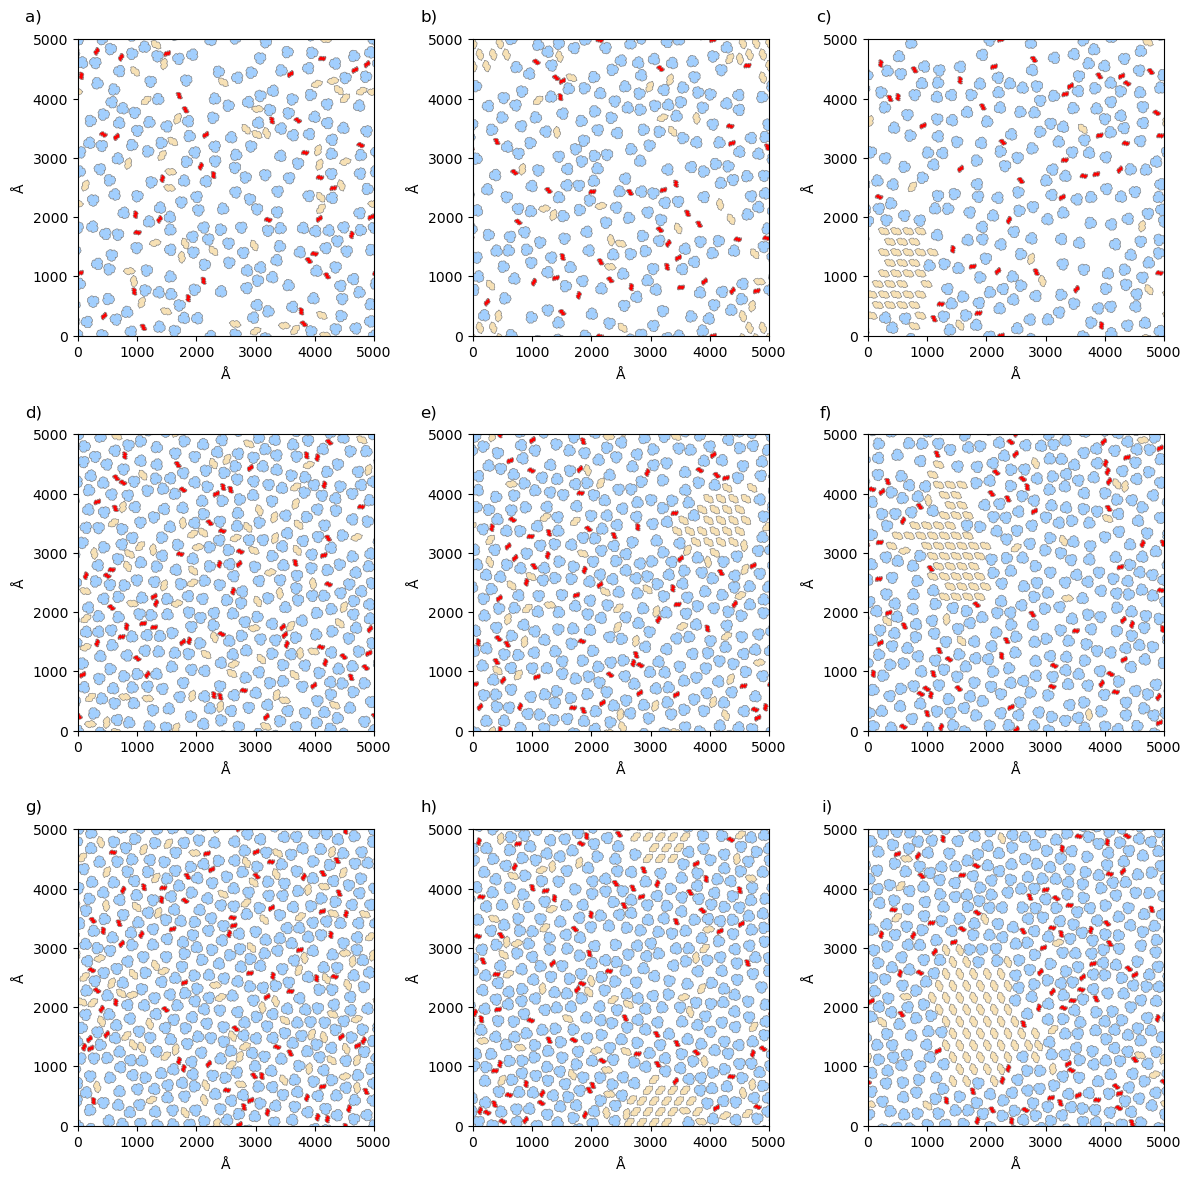

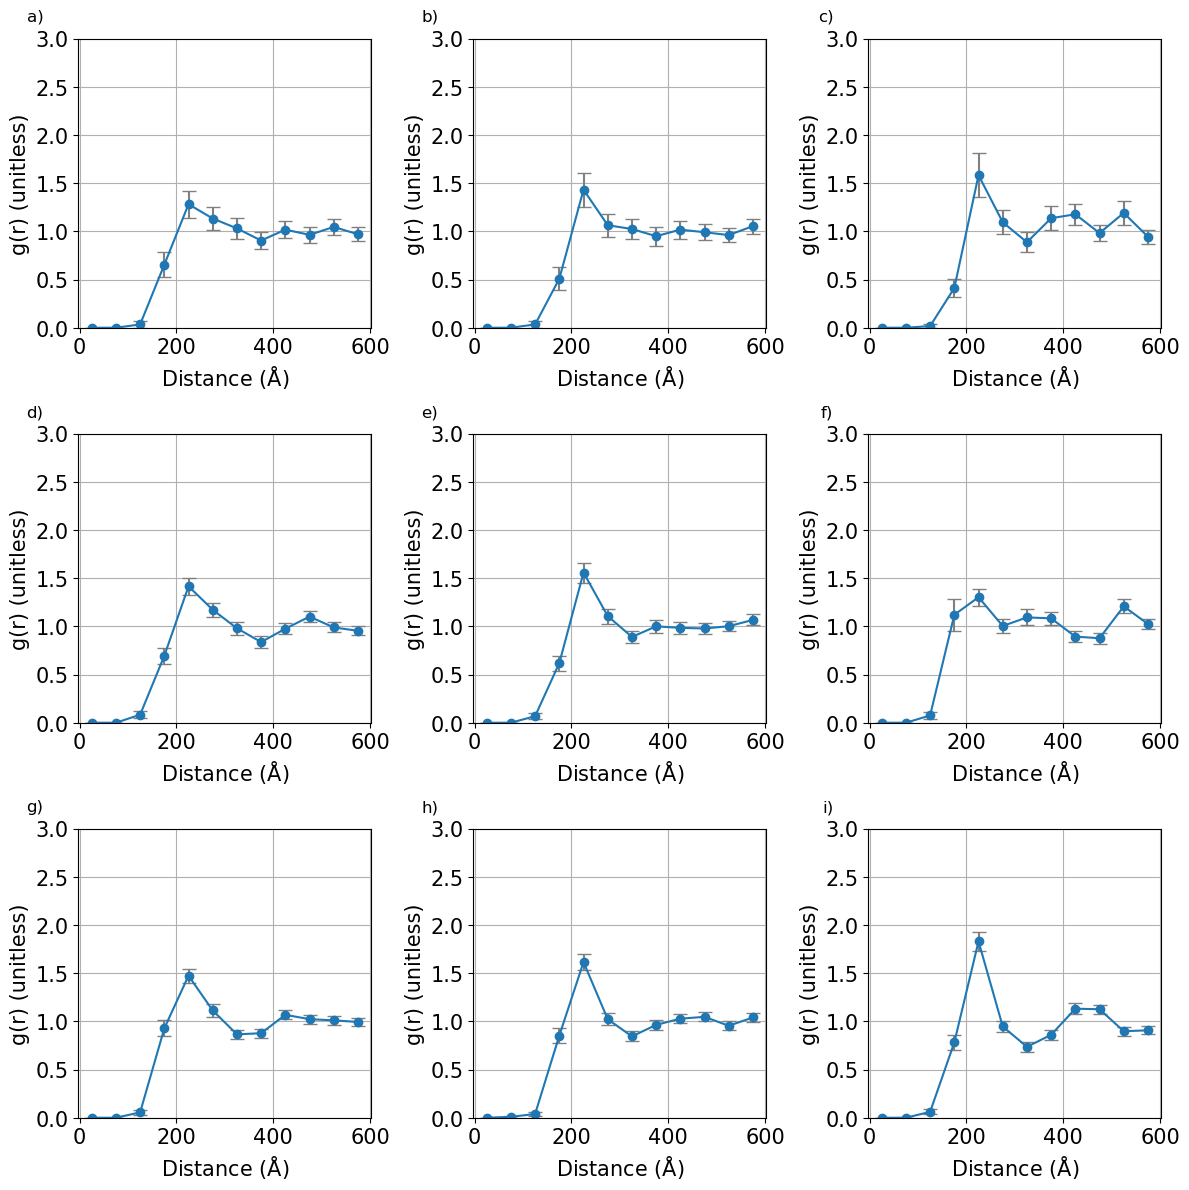

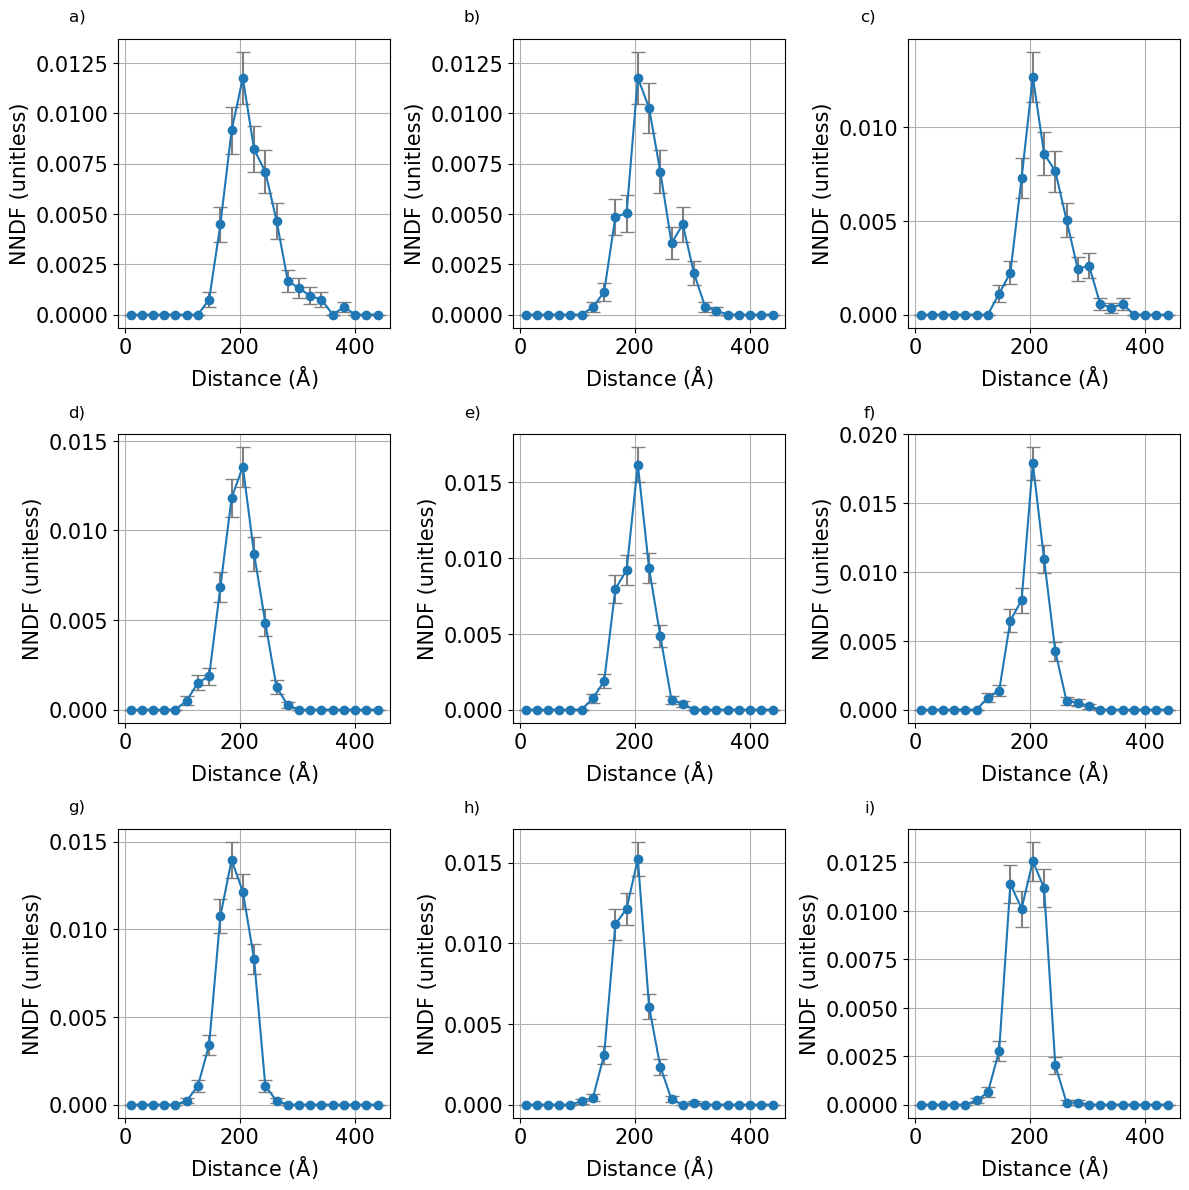

In [8]:
layout = [
    ["a", "b", "c"],
    ["d", "e", "f"],
    ["g", "h", "i"],
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig2, axes2 = plt.subplots(3, 3, figsize=(12, 12))
fig3, axes3 = plt.subplots(3, 3, figsize=(12, 12))



for idx1, i in enumerate([40, 60, 70]):
    for idx2,j in enumerate([0, 0.4, 0.8]):
        plot_membrane(f"../output/avg_membrane_3WU2-PSII-ThermosynVul_crystal/polygons_avg_membrane_{i}_3WU2-PSII-ThermosynVul_1.2_{j}_1-7.wkt",
            ax=axes[idx1, idx2]
            )
        
        p = cm.geo_utils.readwkt(Path(f"../output/avg_membrane_3WU2-PSII-ThermosynVul_crystal/polygons_avg_membrane_{i}_3WU2-PSII-ThermosynVul_1.2_{j}_1-7.wkt"))
        centroids = np.array([i.centroid.xy for i in p])  # your input
        centroids = centroids.reshape(len(centroids),2)
        gr, gr_std, gr_sem, r = rdf(centroids, n_bins=12, box_size=5000, r_max=600)
        G_empirical, G_std, g_nn_empirical, g_nn_std, r2 = nndf(centroids, n_bins=23, box_size = 5000, r_max=450)

        axes2[idx1, idx2].errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes2[idx1, idx2].grid()
        axes2[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes2[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes2[idx1, idx2].set_ylabel("g(r) (unitless)", size=15)
        axes2[idx1, idx2].set_ylim(0, 3)

        axes3[idx1, idx2].errorbar(r2, g_nn_empirical, g_nn_std, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes3[idx1, idx2].grid()
        axes3[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes3[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes3[idx1, idx2].set_ylabel("NNDF (unitless)", size=15)

flat_labels = [key for row in layout for key in row]

for ax, key in zip(axes.flatten(), flat_labels):
    ax.text(-0.12, 1.05, f"{key})",
           transform=ax.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax2, key in zip(axes2.flatten(), flat_labels):
    ax2.text(-0.12, 1.05, f"{key})",
           transform=ax2.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
    
for ax3, key in zip(axes3.flatten(), flat_labels):
    ax3.text(-0.12, 1.05, f"{key})",
           transform=ax3.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)

fig.tight_layout()
fig.savefig(PIC_DIR/ "psii_crystals_membrane.png", dpi = 300)

fig2.tight_layout()
fig2.savefig(PIC_DIR/ "rdf_psii_crystals_membrane.png", dpi = 300)

fig3.tight_layout()
fig3.savefig(PIC_DIR/ "nndf_psii_crystals_membrane.png", dpi = 300)

## Plot membrane with PSI crystaline arrays (four small arrays)

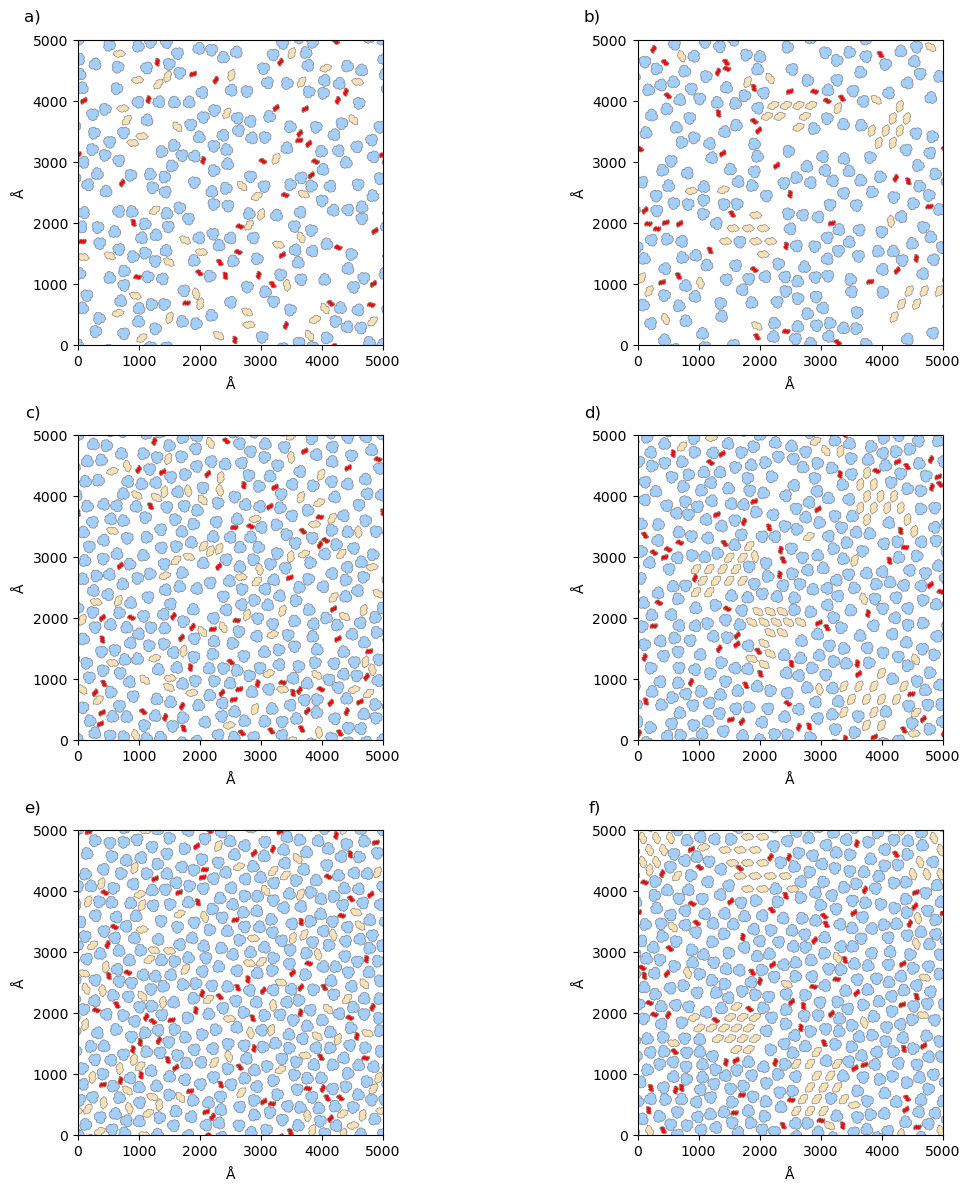

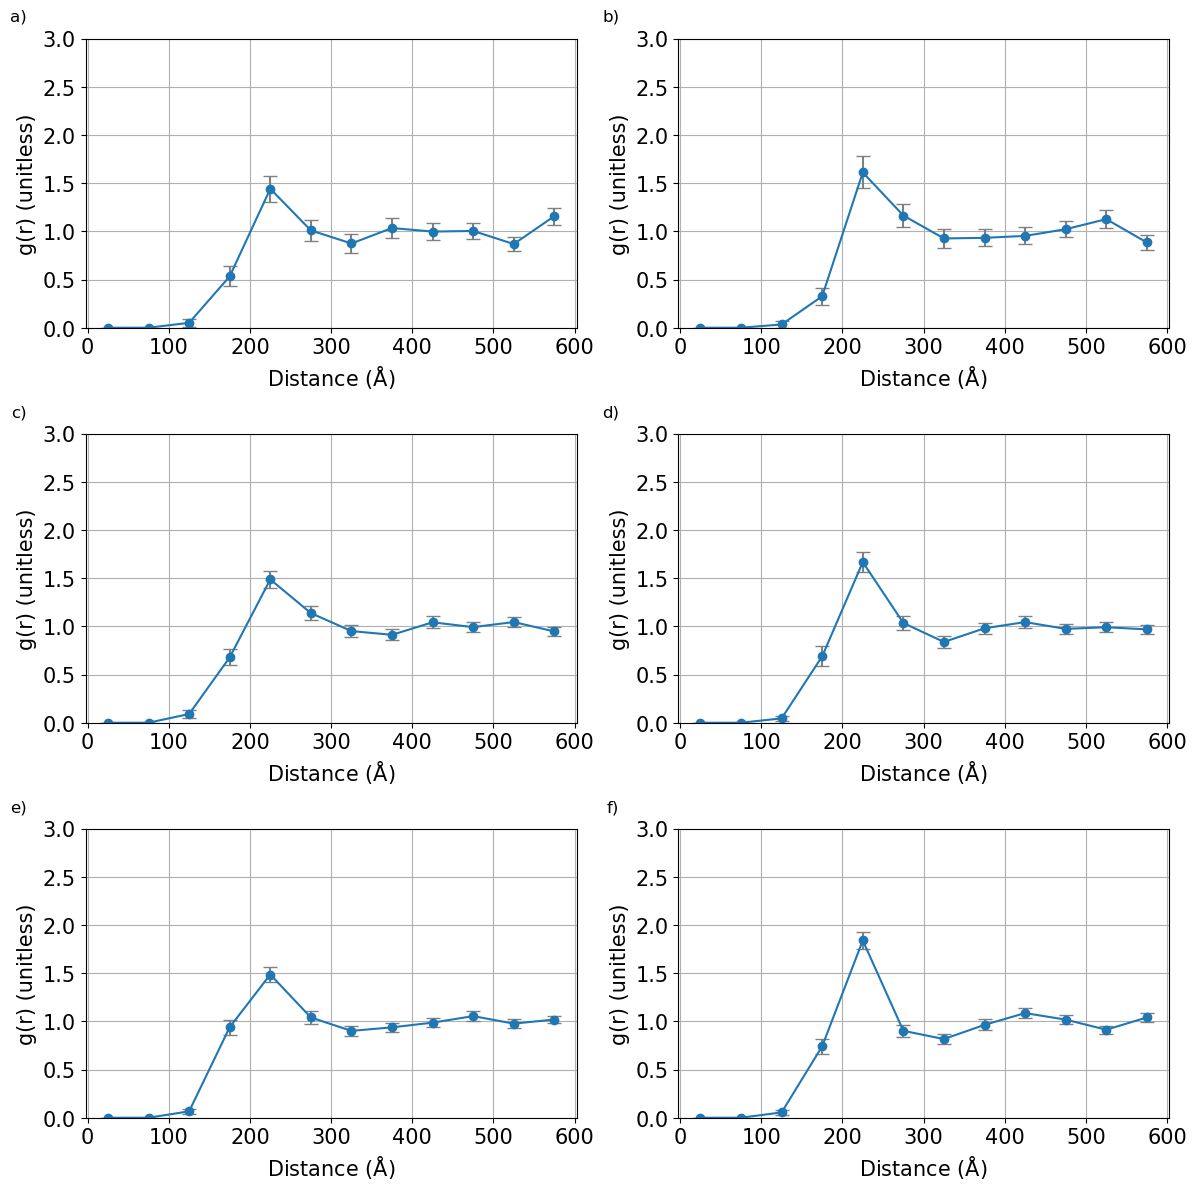

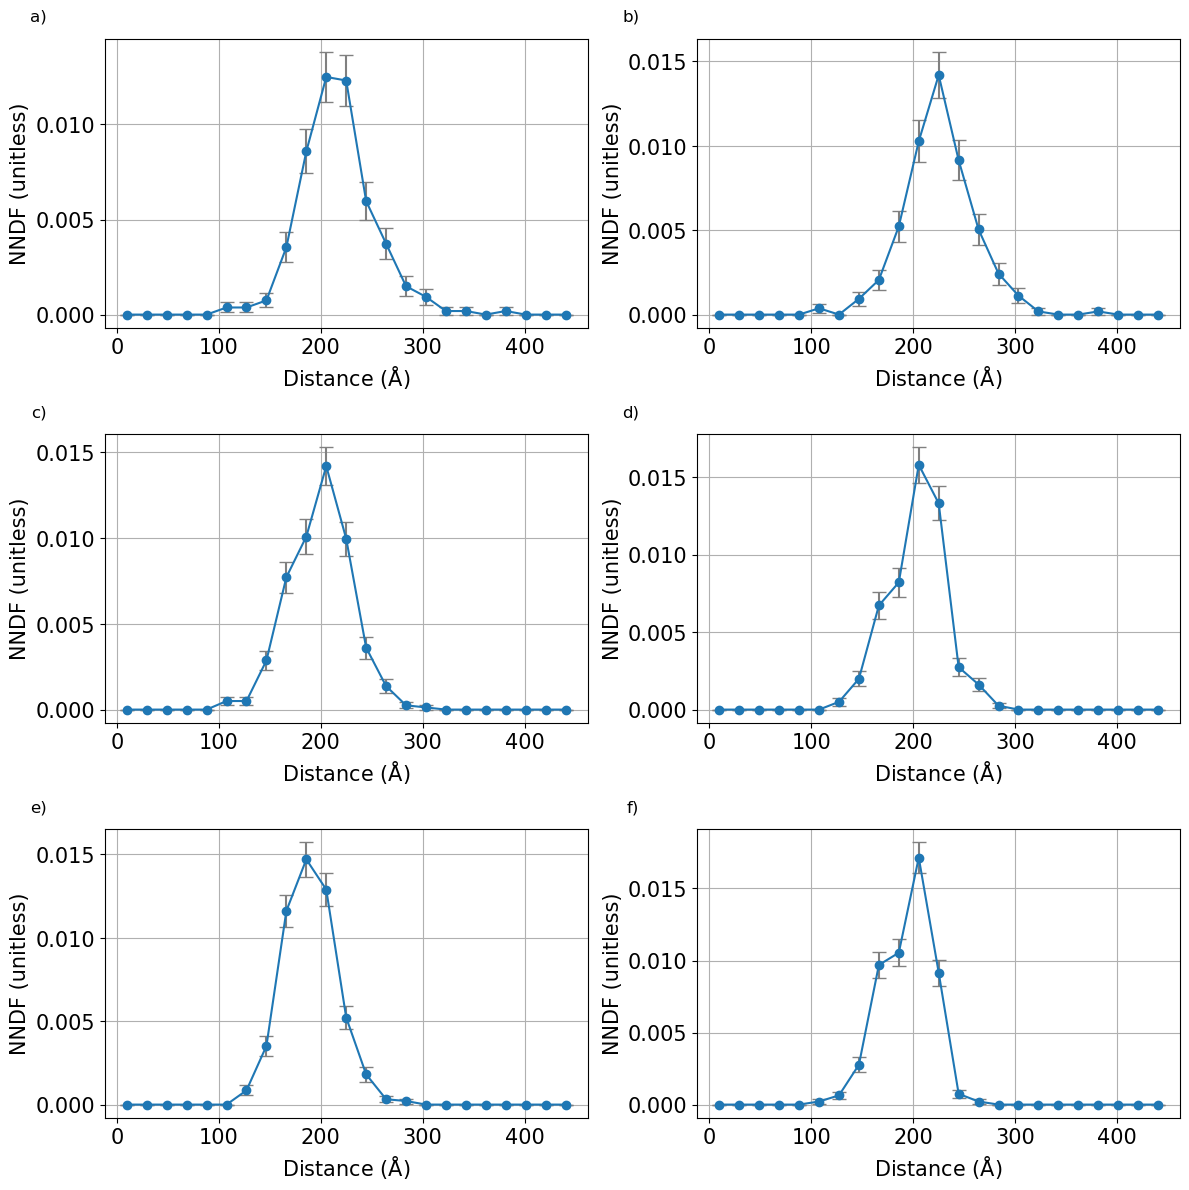

In [9]:
layout = [
    ["a", "b"],
    ["c", "d"],
    ["e", "f"],
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig2, axes2 = plt.subplots(3, 2, figsize=(12, 12))
fig3, axes3 = plt.subplots(3, 2, figsize=(12, 12))



for idx1, i in enumerate([40, 60, 70]):
    for idx2,j in enumerate([0, 0.2]):
        plot_membrane(f"../output/avg_membrane_3WU2-PSII-ThermosynVul_crystal_small/polygons_avg_membrane_{i}_3WU2-PSII-ThermosynVul_1.2_{j}_4-7.wkt",
            ax=axes[idx1, idx2]
            )
        
        p = cm.geo_utils.readwkt(Path(f"../output/avg_membrane_3WU2-PSII-ThermosynVul_crystal_small/polygons_avg_membrane_{i}_3WU2-PSII-ThermosynVul_1.2_{j}_4-7.wkt"))
        centroids = np.array([i.centroid.xy for i in p])  # your input
        centroids = centroids.reshape(len(centroids),2)
        gr, gr_std, gr_sem, r = rdf(centroids, n_bins=12, box_size=5000, r_max=600)
        G_empirical, G_std, g_nn_empirical, g_nn_std, r2 = nndf(centroids, n_bins=23, box_size = 5000, r_max=450)

        axes2[idx1, idx2].errorbar(r, gr, 1.96*gr_sem, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes2[idx1, idx2].grid()
        axes2[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes2[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes2[idx1, idx2].set_ylabel("g(r) (unitless)", size=15)
        axes2[idx1, idx2].set_ylim(0, 3)

        axes3[idx1, idx2].errorbar(r2, g_nn_empirical, g_nn_std, fmt="o-", ecolor="grey", elinewidth=1.5, capsize=5, markersize=6)
        axes3[idx1, idx2].grid()
        axes3[idx1, idx2].tick_params(axis="both", labelsize=15)
        axes3[idx1, idx2].set_xlabel(r"Distance ($\mathrm{\AA}$)", size=15)
        axes3[idx1, idx2].set_ylabel("NNDF (unitless)", size=15)

flat_labels = [key for row in layout for key in row]

for ax, key in zip(axes.flatten(), flat_labels):
    ax.text(-0.12, 1.05, f"{key})",
           transform=ax.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax2, key in zip(axes2.flatten(), flat_labels):
    ax2.text(-0.12, 1.05, f"{key})",
           transform=ax2.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)
    
for ax3, key in zip(axes3.flatten(), flat_labels):
    ax3.text(-0.12, 1.05, f"{key})",
           transform=ax3.transAxes,
           fontsize=12,
           va="bottom", ha="right", clip_on=False)


fig.tight_layout()
fig.savefig(PIC_DIR/ "psii_crystals_membrane_small.png", dpi = 300)

fig2.tight_layout()
fig2.savefig(PIC_DIR/ "rdf_psii_crystals_membrane_small.png", dpi = 300)

fig3.tight_layout()
fig3.savefig(PIC_DIR/ "nndf_psii_crystals_membrane_small.png", dpi = 300)

## Channel width analysis

Processing: avg_membrane, nprot=10, files=10


/tmp/ipykernel_139716/1259994768.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cma.get_cmap("viridis")


../output/avg_membrane/polygons_avg_membrane_10-2.wkt../output/avg_membrane/polygons_avg_membrane_10-4.wkt../output/avg_membrane/polygons_avg_membrane_10-7.wkt../output/avg_membrane/polygons_avg_membrane_10-6.wkt
../output/avg_membrane/polygons_avg_membrane_10-3.wkt../output/avg_membrane/polygons_avg_membrane_10-0.wkt../output/avg_membrane/polygons_avg_membrane_10-5.wkt../output/avg_membrane/polygons_avg_membrane_10-1.wkt../output/avg_membrane/polygons_avg_membrane_10-8.wkt../output/avg_membrane/polygons_avg_membrane_10-9.wkt








Processing: avg_membrane, nprot=20, files=10
../output/avg_membrane/polygons_avg_membrane_20-1.wkt../output/avg_membrane/polygons_avg_membrane_20-7.wkt../output/avg_membrane/polygons_avg_membrane_20-0.wkt../output/avg_membrane/polygons_avg_membrane_20-6.wkt../output/avg_membrane/polygons_avg_membrane_20-8.wkt../output/avg_membrane/polygons_avg_membrane_20-9.wkt../output/avg_membrane/polygons_avg_membrane_20-5.wkt../output/avg_membrane/polygons_avg_membrane

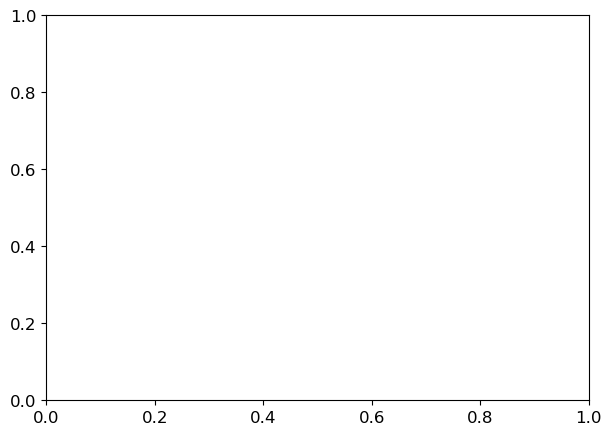

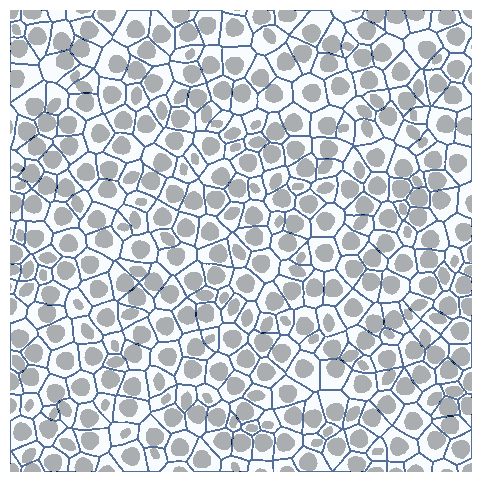

In [12]:


NUMBER_OF_PROTEINS = {
    "avg_membrane": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110],
}

RESOLUTION = 1
STATS = {}


def analyze_one_skeleton(f):
    print(f)
    p = cm.geo_utils.readwkt(f)
    workspace = box(0, 0, 5000, 5000)
    union_shape = unary_union(p)
    coverage = workspace.intersection(union_shape).area / (5000 * 5000)

    skeleton, dist, crop = cm.geo_utils.make_skeleton(
        p, RESOLUTION, 5000, [5000, 10000]
    )

    widths = dist[skeleton] * 2 * RESOLUTION

    skeleton = dilation(skeleton, disk(10))

    del p
    del workspace
    del union_shape
    gc.collect()

    return skeleton, widths, crop, coverage


plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (7, 5),
        "font.size": 13,
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)


for pkey, nprot_lst in NUMBER_OF_PROTEINS.items():
    width_array_dict = {}
    fig, ax = plt.subplots()
    cmap = cma.get_cmap("viridis")
    for nprot in nprot_lst:
        widths_lst = []
        coverage_lst = []
        file_lst = list((OUT / pkey).glob(f"*_{nprot}-*.wkt"))
        #print(file_lst)
        if len(file_lst) == 0:
            continue

        print(f"Processing: {pkey}, nprot={nprot}, files={len(file_lst)}")

        with ProcessPoolExecutor(max_workers=N_PROCESSES) as p:
            fut = p.map(analyze_one_skeleton, file_lst)

        for idx, i in enumerate(fut):
            skeleton, widths, crop, coverage = i

            if pkey == "avg_membrane" and nprot == 50 and idx == 0:
                plt.figure(figsize=(6, 6))
                plt.imshow(~crop, cmap="gray", interpolation="none")
                plt.imshow(skeleton, cmap="Blues", alpha=0.7, interpolation="none")
                plt.axis("off")
                plt.savefig(OUT / f"Medial_Axis_{pkey}_{nprot}.png", dpi=300)

            skeleton, widths, crop, coverage = i
            widths_lst.extend(widths)
            coverage_lst.append(coverage)

        widths_arr = np.array(widths_lst)
        width_array_dict[nprot] = widths_arr
        coverage_mean = round(np.mean(coverage_lst), 2)

        STATS[(pkey, nprot)] = {
            "coverage": coverage_mean,
            "mean_width": float(np.mean(widths_arr)),
            "std_width": float(np.std(widths_arr)),
            "min_width": float(np.min(widths_arr)),
            "median_width": float(np.median(widths_arr)),
            "p10_width": float(np.percentile(widths_arr, 10)),
            "p90_width": float(np.percentile(widths_arr, 90)),
        }


summary_df = pd.DataFrame.from_dict(STATS, orient="index")
summary_df.to_csv(PIC_DIR / "medial_axis_statistics.csv")
print(summary_df)


In [13]:
for pkey, nprot_lst in NUMBER_OF_PROTEINS.items():
    fig, ax = plt.subplots()
    for nprot in nprot_lst:
        coverage_mean = summary_df.loc[(pkey, nprot)]["coverage"]
        widths_arr = width_array_dict[nprot]
        coverage_scaled = coverage_mean**0.5  # or **0.3 for stronger exaggeration
        norm = colors.Normalize(vmin=0, vmax=1)
        kde = gaussian_kde(widths_arr)
        x = np.linspace(0, widths_arr.max(), 500)
        y = kde(x)

        ax.plot(
            x,
            y,
            linewidth=2,
            color=cmap(norm(coverage_mean**0.5)),
            alpha=0.9,
            label=f"{(coverage_mean*100):.2f} %",
        )
        ax.set_xlabel("Channel Width (Å)")
        ax.set_ylabel("Normalized Frequency")
        #ax.set_title(f"Width Distribution in {pkey}")

        ax.legend(title="Coverage", loc="upper left", bbox_to_anchor=(1.05, 1))
        plt.tight_layout()

    fig.savefig(PIC_DIR / f"Medial_Axis_hist_{pkey}_improved.png", dpi=300)
    plt.close(fig)

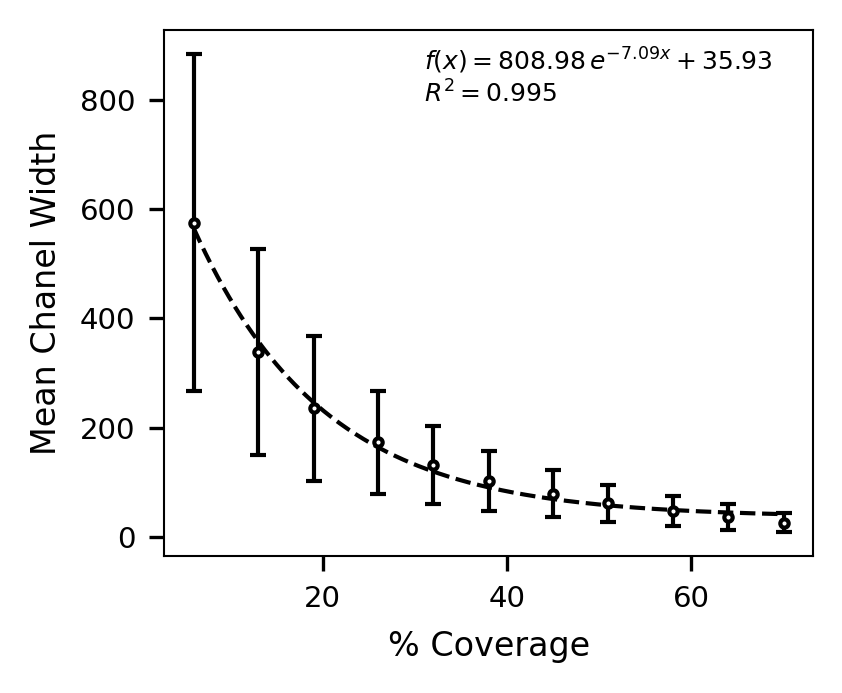

In [14]:
# Extract data
df = summary_df.loc["avg_membrane"]
x = df["coverage"].values 
y = df["mean_width"].values
yerr = df["std_width"].values


# Exponential model
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c


# Fit model
popt, _ = curve_fit(exp_func, x, y, p0=(y[0], 3, y[-1]))
a, b, c = popt

# Compute R²
y_fit = exp_func(x, *popt)
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Generate smooth curve for plotting
x_fit = np.linspace(x.min(), x.max(), 300)
y_fit_curve = exp_func(x_fit, *popt)

# Plot
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)

ax.errorbar(
    x * 100, y, yerr=yerr,
    fmt="o",
    color="black",        # line color
    markerfacecolor="white",   # marker fill
    markeredgecolor="black",   # marker border
    markeredgewidth=1,       # border thickness
    markersize=2,
    capsize=2,
    linewidth=1,
)

ax.plot(x_fit * 100, y_fit_curve, c="k", linestyle="--", lw=1)

# Annotation (smaller, no box)
eq_text = (
    rf"$f(x) = {a:.2f}\, e^{{-{b:.2f} x}} + {c:.2f}$"
    "\n"
    rf"$R^2 = {r2:.3f}$"
)
ax.text(
    0.4,
    0.97,
    eq_text,
    transform=ax.transAxes,
    fontsize=6,  # smaller annotation
    verticalalignment="top",
)

# Labels & styling
ax.set_xlabel("% Coverage", fontsize=8)
ax.set_ylabel("Mean Chanel Width", fontsize=8)
ax.tick_params(axis="both", which="major", labelsize=7)
# ax.set_title("avg_membrane (exp fit)", fontsize=9, pad=3)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig(PIC_DIR / f"Medial_axis_mean_coverage_mean_width.png", dpi=300)
plt.show()
